# Topic 10: Koopman - Supplementary Interactive Material

# HAVOK / Koopman Analysis on Lorenz System

In this notebook, we demonstrate how to extract a **linear-plus-forcing model**
from a single chaotic time series using the HAVOK (Hankel Alternative View of Koopman) framework.

We reconstruct the dynamics using the model

$$
\dot{v}(t) = A\,v(t) + B\,v_r(t)
$$

where:

- $v(t) \in \mathbb{R}^{r-1}$ are the **linear latent variables**
- $v_r(t)$ is an **external forcing coordinate**
- $A$ is the Koopman linear dynamics matrix
- $B$ couples the forcing into the linear system

This decomposition separates Lorenz chaos into:

- smooth, nearly-linear motion  
- intermittent bursts of forcing  

---

## 1. Simulating the Lorenz System

We generate a long trajectory from the Lorenz equations:

$$
\dot{x} = \sigma(y - x), \qquad
\dot{y} = x(\rho - z) - y, \qquad
\dot{z} = xy - \beta z.
$$

---

## 2. Delay-Embedding via Hankel Matrix

We embed the scalar signal $x(t)$ into a higher-dimensional vector using delays:

$$
H =
\begin{bmatrix}
x_1 & x_2 & x_3 & \dots \\
x_2 & x_3 & x_4 & \dots \\
\vdots & & &
\end{bmatrix}
$$

This uses Takens' theorem to reconstruct the underlying attractor from one coordinate.

---

## 3. SVD of the Hankel Matrix

We compute:

$$
H = U \Sigma V^\top.
$$

The columns of $V$ give the **temporal HAVOK coordinates**
$(v_1(t), \dots, v_r(t))$.

---

## 4. Time Derivative of HAVOK Coordinates

We approximate the derivative using the 4th-order centered difference:

$$
\dot{v}(t_k)
\approx
\frac{-v_{k+2} + 8v_{k+1} - 8v_{k-1} + v_{k-2}}{12 \,\Delta t}.
$$

These derivatives feed the Koopman regression.

---

## 5. Koopman Regression

We solve the least-squares problem

$$
\dot{V} = V \, \Xi
$$

and then partition

$$
A = \Xi_{1:r-1, \, 1:r-1}, \qquad
B = \Xi_{r, \, 1:r-1}.
$$

Here:

- $A$ contains the linear dynamics
- $B$ shows how the forcing enters the system

The final coordinate $v_r(t)$ becomes the **forcing term** that produces chaotic transitions.

---

## 6. HAVOK Modes

The first few modes $v_1(t), v_2(t), \ldots, v_{r-1}(t)$ describe coherent linear dynamics.

---

## 7. Forcing Mode

The last coordinate is the forcing:

$$
v_r(t)
$$

It spikes sharply when the system switches between Lorenz wings,
and remains small during regular motion.

This is the hallmark of HAVOK:
**chaos = linear dynamics + sparse intermittent forcing**.

---


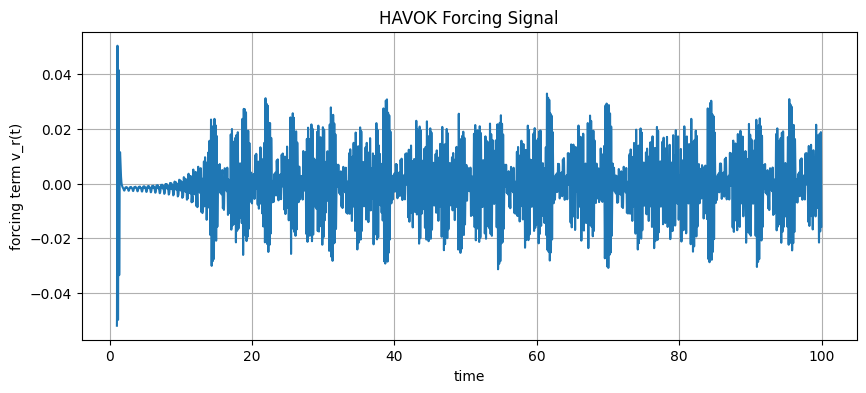

HAVOK model constructed.
A shape: (14, 14)
B shape: (14,)


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =====================================================
# 1. Lorenz dynamics
# =====================================================
def lorenz_rhs(t, x, sigma=10.0, beta=8/3, rho=28.0):
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2]
    ]

dt = 0.01
tspan = np.arange(0, 100, dt)
x0 = np.array([1.0, 1.0, 1.0])

sol = solve_ivp(
    fun=lambda t, x: lorenz_rhs(t, x),
    t_span=[tspan[0], tspan[-1]],
    y0=x0,
    t_eval=tspan,
    rtol=1e-10, atol=1e-10
)

x = sol.y[0, :]   # Only x-coordinate (matches MATLAB)

# =====================================================
# 2. Hankel matrix construction
# =====================================================
stackmax = 100
H = np.zeros((stackmax, len(x) - stackmax))

for k in range(stackmax):
    H[k, :] = x[k : k + (len(x) - stackmax)]

# =====================================================
# 3. SVD & mode selection
# =====================================================
U, S, Vt = np.linalg.svd(H, full_matrices=False)
r = 15
V = Vt[:r, :].T        # shape = (T-stackmax, r)

# =====================================================
# 4. 4th-order central difference on V-modes
# =====================================================
dV = np.zeros_like(V)
for k in range(2, len(V) - 2):
    dV[k] = (-V[k+2] + 8*V[k+1] - 8*V[k-1] + V[k-2]) / (12 * dt)

# =====================================================
# 5. Trim edges lost to differentiation
# =====================================================
# V : shape (N, r)
# Remove 2 samples at each boundary → (N-4, r)
V_trim = V[2:-2]
dV_trim = dV[2:-2]

# Now V_trim corresponds to times:
# Originally V begins at t = 0 + (stackmax * dt)
# After trimming → shift by +2 dt and -2 dt
t_trim = tspan[stackmax + 2 : -(2)]  

# Sanity check
assert len(t_trim) == V_trim.shape[0]

# =====================================================
# 6. Fit linear model: dV = V * Xi
# =====================================================
Xi = np.linalg.lstsq(V_trim, dV_trim, rcond=None)[0]

# Koopman components
A = Xi[:r-1, :r-1]
B = Xi[r-1, :r-1]

# =====================================================
# 7. Extract forcing term v_r(t)
# =====================================================
vr = V_trim[:, r-1]

plt.figure(figsize=(10, 4))
plt.plot(t_trim, vr)
plt.xlabel("time")
plt.ylabel("forcing term v_r(t)")
plt.title("HAVOK Forcing Signal")
plt.grid(True)
plt.show()

print("HAVOK model constructed.")
print("A shape:", A.shape)
print("B shape:", B.shape)


## Additional Plots

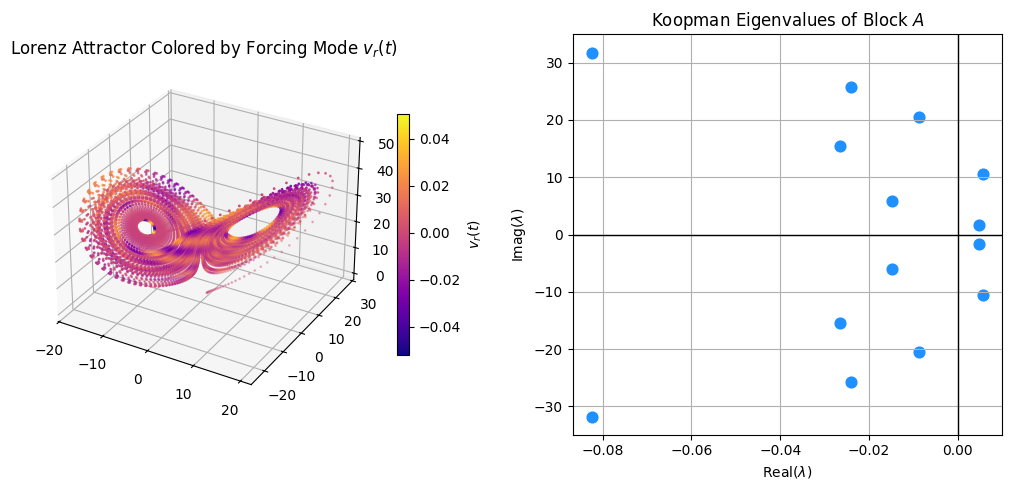

In [3]:
# =====================================================
# 8. PLOT #1: Forcing spikes over Lorenz attractor
# =====================================================

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(121, projection='3d')

# Color by forcing term (interpolated to Lorenz length)
vr_full = np.zeros_like(x)
vr_full[stackmax+2:-2] = vr  # embed forcing into full time vector

p = ax.scatter(sol.y[0], sol.y[1], sol.y[2],
               c=vr_full, cmap='plasma', s=1)
ax.set_title("Lorenz Attractor Colored by Forcing Mode $v_r(t)$")
plt.colorbar(p, ax=ax, shrink=0.6, label="$v_r(t)$")

# =====================================================
# 9.PLOT #2: Koopman eigenvalues of linear block A
# =====================================================
ax2 = fig.add_subplot(122)
eigvals = np.linalg.eigvals(A)

ax2.scatter(eigvals.real, eigvals.imag, c='dodgerblue', s=60)
ax2.axvline(0, color='k', lw=1)
ax2.axhline(0, color='k', lw=1)
ax2.set_xlabel("Real($\lambda$)")
ax2.set_ylabel("Imag($\lambda$)")
ax2.set_title("Koopman Eigenvalues of Block $A$")
ax2.grid(True)

plt.tight_layout()
plt.show()
